# Grid → Gemini outfit experiment

Show the model **one PNG** of your wardrobe grid (filenames as subplot titles) plus a **text query**. It returns JSON: **`combinations`** with `top`, `bottom`, and `reasoning`.

**How to use this notebook**
1. Run **sections 1–7** once per session (imports → prompt → small helper cells → API → display helper).
2. Edit **section 8 — Experiment config** (`USER_QUERY`, paths, model).
3. Run **Step A–D** in order (preview → API → optional JSON print → plots).

**One query per experiment** — change `USER_QUERY` in section 8 and re-run Step B–D.

**Setup:** `pip install -r requirements.txt`, `.env` with **`OPENROUTER_API_KEY`**. Optional: `OPENROUTER_HTTP_REFERER`, `OPENROUTER_APP_TITLE`.

Each API run overwrites `outputs/wardrobe_grid_for_model.png` (the exact image sent to the model).


## 1. Imports and project paths

Run this first. Defines `ROOT` and ensures `outputs/` exists.


In [2]:
from __future__ import annotations

import base64
import json
import math
import mimetypes
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image

load_dotenv()


def project_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "notebooks").is_dir() and here.name == "notebooks":
        return here.parent
    return here


ROOT = project_root()
(ROOT / "outputs").mkdir(parents=True, exist_ok=True)


## 2. System prompt (edit this)

Sent as the model **system** message. Change rules or JSON shape here without touching the Python below.


In [3]:
GRID_OUTFIT_SYSTEM = """You are a fashion stylist. The user message contains a natural-language outfit request (e.g. season, occasion, formality).

You receive ONE composite image: a grid of wardrobe photos. **Each subplot title is the exact filename** of that garment on disk (e.g. `shirt.jpg`). You must only reference filenames that appear as those titles.

Rules:
- Build **outfit combinations** from the grid items only.
- **`bottom`**: exactly one filename (pants, skirt, shorts, etc.).
- **`top`**: either one filename, **or** a JSON array of filenames ordered **outer layer → inner** when layering (e.g. jacket then tee).
- Do not use a filename that is not shown in the grid. Do not invent filenames.
- **`reasoning`**: one string per combination explaining fit to the query and why the pairing works (colors, formality, season, silhouette).

Return ONLY valid JSON with this shape (no markdown fences):
{"combinations": [{"top": "<filename OR [filenames]>", "bottom": "<filename>", "reasoning": "<string>"}]}

Sort combinations from best match to weaker. If no valid outfit exists, return {"combinations": []}.
"""


## 3. Helpers — files, data URLs, OpenRouter client

Low-level utilities for the grid renderer and API call.


In [4]:
def _image_bytes_and_mime(path: Path) -> tuple[bytes, str]:
    raw = path.read_bytes()
    mime, _ = mimetypes.guess_type(path.name)
    if not mime:
        mime = "image/jpeg"
    return raw, mime


def _data_url(path: Path) -> str:
    raw, mime = _image_bytes_and_mime(path)
    b64 = base64.standard_b64encode(raw).decode("ascii")
    return f"data:{mime};base64,{b64}"


def openrouter_client() -> OpenAI:
    default_headers = {
        "X-Title": os.environ.get("OPENROUTER_APP_TITLE", "Fashion grid outfit experiment"),
    }
    referer = os.environ.get("OPENROUTER_HTTP_REFERER")
    if referer:
        default_headers["HTTP-Referer"] = referer
    return OpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
        default_headers=default_headers,
    )


def list_wardrobe_images(
    folder: str | Path,
    extensions: set[str] | None = None,
) -> list[Path]:
    folder = Path(folder).expanduser().resolve()
    if extensions is None:
        extensions = {".jpg", ".jpeg", ".png", ".webp", ".gif", ".bmp"}
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in extensions
    )


## 4. Helpers — wardrobe grid (preview + PNG for vision)

- `show_image_grid` — figure in the notebook.
- `render_wardrobe_grid_png` — same layout saved to disk; that file is base64-encoded for the API.

Match `NCOLS` / `THUMB` in section 8 to what you pass here.


In [5]:
def show_image_grid(
    folder: str | Path,
    *,
    ncols: int = 4,
    thumb: int = 160,
    extensions: set[str] | None = None,
) -> None:
    folder = Path(folder).expanduser().resolve()
    paths = list_wardrobe_images(folder, extensions)
    if not paths:
        print(f"No images in {folder}")
        return

    n = len(paths)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.6))
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    else:
        axes_list = axes.flatten()

    for i, ax in enumerate(axes_list):
        if i < n:
            p = paths[i]
            im = Image.open(p).convert("RGB")
            im.thumbnail((thumb, thumb))
            ax.imshow(im)
            ax.set_title(p.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def render_wardrobe_grid_png(
    folder: str | Path,
    out_png: Path,
    *,
    ncols: int = 4,
    thumb: int = 160,
    extensions: set[str] | None = None,
) -> Path:
    # Same subplot layout as show_image_grid; written to PNG for the vision model.
    folder = Path(folder).expanduser().resolve()
    paths = list_wardrobe_images(folder, extensions)
    if not paths:
        raise FileNotFoundError(f"No images in {folder}")

    n = len(paths)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.6))
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    else:
        axes_list = axes.flatten()

    for i, ax in enumerate(axes_list):
        if i < n:
            p = paths[i]
            im = Image.open(p).convert("RGB")
            im.thumbnail((thumb, thumb))
            ax.imshow(im)
            ax.set_title(p.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_png


## 5. Helpers — normalize model JSON

Coerces `reasons` → `reasoning` if needed; extracts top filenames for plotting.


In [6]:
def normalize_combo_row(c: dict[str, Any]) -> dict[str, Any]:
    out = dict(c)
    if "reasoning" not in out and "reasons" in out:
        r = out.get("reasons")
        if isinstance(r, list):
            out["reasoning"] = " ".join(str(x) for x in r)
        else:
            out["reasoning"] = str(r)
    return out


def top_filenames_from_combo(combo: dict[str, Any]) -> list[str]:
    t = combo.get("top")
    if isinstance(t, list):
        return [str(x) for x in t]
    if t is None:
        return []
    return [str(t)]


## 6. API — `recommend_outfits_from_grid`

Builds the grid PNG, then OpenRouter chat with `response_format: json_object`.

**Inputs from section 8:** `images_dir`, `user_query`, `model`, `ncols`, `thumb`, optional `temperature`, `grid_out`.


In [7]:
def recommend_outfits_from_grid(
    *,
    images_dir: Path,
    user_query: str,
    model: str,
    ncols: int = 4,
    thumb: int = 160,
    temperature: float = 0.4,
    grid_out: Path | None = None,
) -> dict[str, Any]:
    grid_out = grid_out or (ROOT / "outputs" / "wardrobe_grid_for_model.png")
    render_wardrobe_grid_png(images_dir, grid_out, ncols=ncols, thumb=thumb)

    client = openrouter_client()
    data_url = _data_url(grid_out)
    user_text = (
        f"User query:\n{user_query}\n\n"
        "The attached image is the wardrobe grid. Each subplot title is the exact filename to use in JSON."
    )

    r = client.chat.completions.create(
        model=model,
        temperature=temperature,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": GRID_OUTFIT_SYSTEM},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_text},
                    {"type": "image_url", "image_url": {"url": data_url}},
                ],
            },
        ],
    )
    text = r.choices[0].message.content
    if not text:
        raise ValueError("Empty model response")
    data = json.loads(text)
    combos = data.get("combinations", [])
    if isinstance(combos, list):
        data["combinations"] = [normalize_combo_row(x) for x in combos if isinstance(x, dict)]
    return data


## 7. Helpers — display recommendations

One row of thumbnails per combination, then printed reasoning. Re-run anytime after `result` exists.


In [8]:
def display_recommendations(
    result: dict[str, Any],
    images_dir: str | Path,
    *,
    thumb: int = 180,
) -> None:
    images_dir = Path(images_dir).expanduser().resolve()
    combos = result.get("combinations") or []
    if not combos:
        print("No combinations in result")
        return

    for idx, combo in enumerate(combos, start=1):
        combo = normalize_combo_row(combo)
        tops = top_filenames_from_combo(combo)
        bot = combo.get("bottom")
        reason = combo.get("reasoning", "")

        paths: list[Path] = []
        labels: list[str] = []
        for name in tops:
            paths.append(images_dir / name)
            labels.append(f"top: {name}")
        if bot:
            paths.append(images_dir / str(bot))
            labels.append(f"bottom: {bot}")

        n = len(paths)
        if n == 0:
            print(f"Combination #{idx}: no top/bottom filenames to show — {reason}")
            continue

        fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.8))
        if n == 1:
            axes = [axes]
        else:
            axes = list(axes)

        for ax, pth, lab in zip(axes, paths, labels):
            ax.axis("off")
            if pth.is_file():
                im = Image.open(pth).convert("RGB")
                im.thumbnail((thumb, thumb))
                ax.imshow(im)
            else:
                ax.text(0.5, 0.5, f"missing\n{pth.name}", ha="center", va="center", fontsize=9)
            ax.set_title(lab, fontsize=9)

        fig.suptitle(f"Combination #{idx}", fontsize=11, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()

        print(f"\n### #{idx} reasoning\n{reason}\n")


---

## 8. Experiment config (user inputs)

Edit here, then run **Step A–D**. Re-run Step B after changing `USER_QUERY` or `MODEL`.


In [12]:
IMAGES_DIR = ROOT / "images"
USER_QUERY = "Season: Summer, Occassion: Office Wear"

# Vision + JSON via OpenRouter
MODEL = "google/gemini-3.1-flash-image-preview"

NCOLS = 4
THUMB = 160
TEMPERATURE = 0.4

GRID_FOR_MODEL_PATH = ROOT / "outputs" / "wardrobe_grid_for_model.png"
DISPLAY_THUMB = 200


### Step A — Preview wardrobe grid


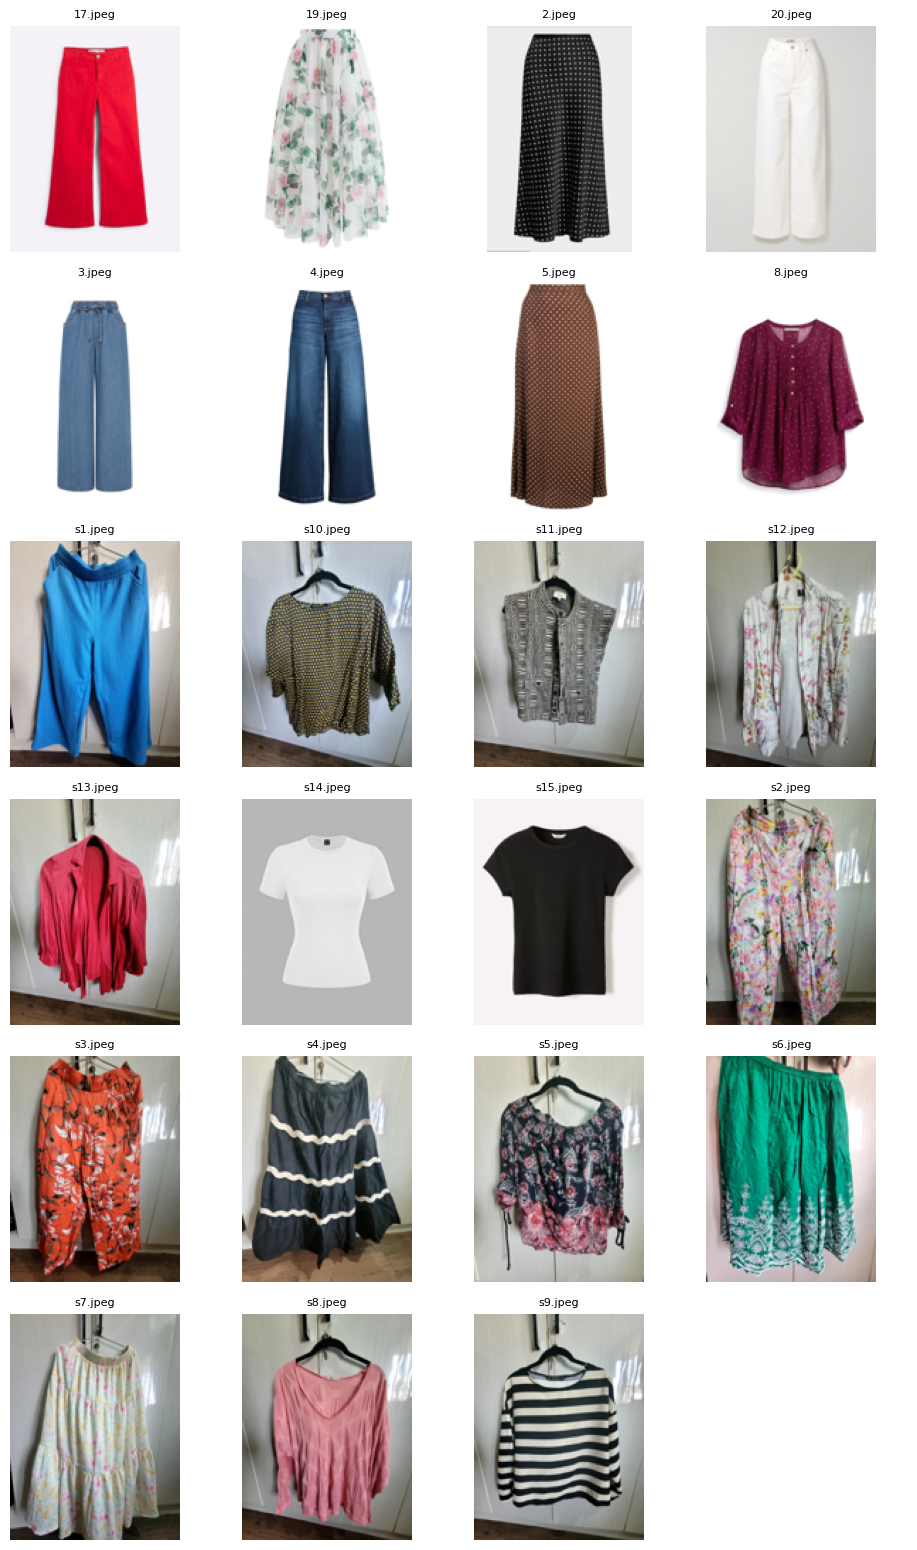

In [13]:
show_image_grid(IMAGES_DIR, ncols=NCOLS, thumb=THUMB)


### Step B — Call the model (produces `result`)


In [14]:
result = recommend_outfits_from_grid(
    images_dir=IMAGES_DIR,
    user_query=USER_QUERY,
    model=MODEL,
    ncols=NCOLS,
    thumb=THUMB,
    temperature=TEMPERATURE,
    grid_out=GRID_FOR_MODEL_PATH,
)


### Step C — Raw JSON (optional)


In [15]:
print(json.dumps(result, ensure_ascii=False, indent=2))


{
  "combinations": [
    {
      "top": "s13.jpeg",
      "bottom": "20.jpeg",
      "reasoning": "A classic and professional combination. The crisp white wide-leg pants are perfect for summer, and the red button-down shirt adds a bold, office-appropriate pop of color."
    },
    {
      "top": "s10.jpeg",
      "bottom": "2.jpeg",
      "reasoning": "This outfit is polished and patterned. The black dotted midi skirt is a staple for office wear, and the yellow patterned blouse provides a cheerful, summer-appropriate contrast that remains professional."
    },
    {
      "top": [
        "s12.jpeg",
        "s14.jpeg"
      ],
      "bottom": "s1.jpeg",
      "reasoning": "This layered look uses a floral blazer to dress up a simple white t-shirt, making it suitable for a modern office. The bright blue wide-leg pants add a modern touch and pair well with the white and floral elements for a summer feel."
    },
    {
      "top": "s8.jpeg",
      "bottom": "5.jpeg",
      "reasoning": 

### Step D — Visualize combinations + reasoning


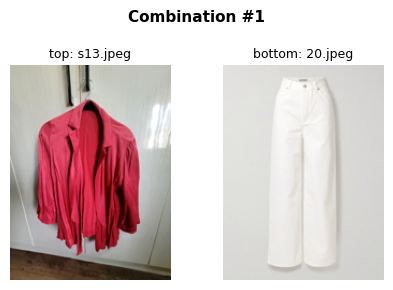


### #1 reasoning
A classic and professional combination. The crisp white wide-leg pants are perfect for summer, and the red button-down shirt adds a bold, office-appropriate pop of color.



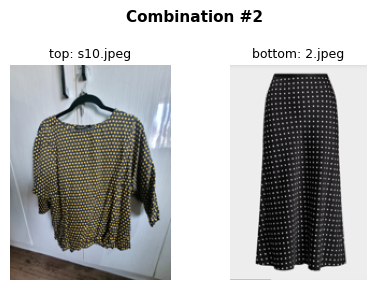


### #2 reasoning
This outfit is polished and patterned. The black dotted midi skirt is a staple for office wear, and the yellow patterned blouse provides a cheerful, summer-appropriate contrast that remains professional.



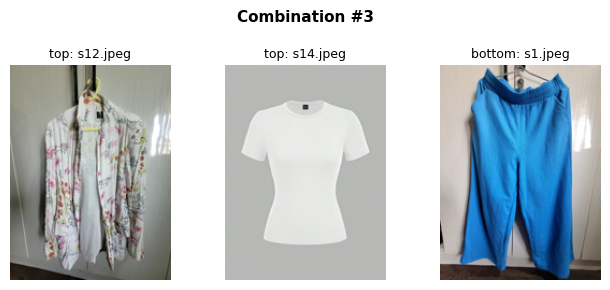


### #3 reasoning
This layered look uses a floral blazer to dress up a simple white t-shirt, making it suitable for a modern office. The bright blue wide-leg pants add a modern touch and pair well with the white and floral elements for a summer feel.



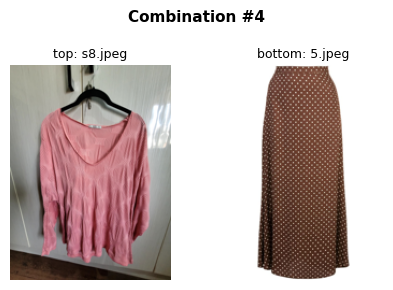


### #4 reasoning
An elegant and feminine choice. The soft pink blouse is a professional color, and the brown patterned maxi skirt adds texture and sophistication. The maxi length is suitable for an office environment.



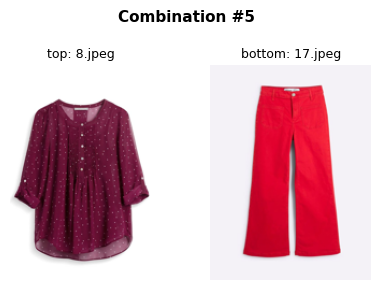


### #5 reasoning
A bold, modern look. The maroon blouse has a subtle pattern, and the red wide-leg pants make a strong professional statement. Both items are professional in cut and fabric.



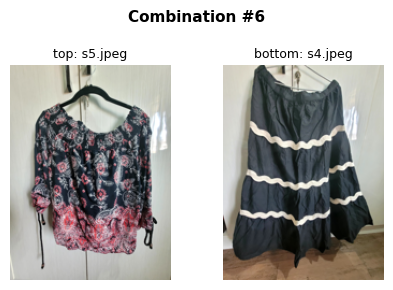


### #6 reasoning
A simple and clean outfit. The dark floral blouse adds a touch of summer pattern, while the black tiered skirt is a versatile and appropriate office piece.



In [16]:
display_recommendations(result, IMAGES_DIR, thumb=DISPLAY_THUMB)
